# 선형회귀 기초

## 선형회귀(Linear Regression) 공식
$y=ax+b$

$오차(error) : e = y_i - \hat y_i \quad where \ \hat y_i = ax_i+b$

$ MSE(Cost) = \frac {1}{n} \sum (y_i - \hat y_i)^2 = \frac {1}{n} \sum (y_i-(ax_i+b))^2 \quad where \ MSE = Mean \ Squared \ Error \ (평균제곱오차)$

$\frac {\partial cost}{\partial a} = -\frac {2}{n}\sum x_i (y_i-(ax_i+b))$

$\frac {\partial cost}{\partial b} = -\frac {2}{n}\sum (y_i-(ax_i+b))$

$a = a - \alpha \cdot \frac {\partial cost}{\partial a} $

$b = b - \alpha \cdot \frac {\partial cost}{\partial b} \quad where \ \alpha : learning \ rate \ (<1)$

In [ ]:
#@title MSE 공식 구현
import random
import numpy as np
x = np.array([2,4,6,8])
y = np.array([81,93,91,97])
#print(x,y)

# a, b 초기화
a = random.random()
b = random.random()
print(f'학습 전 a : {a:.4f}, b : {b:.4f}')

# 학습률 지정
lr = 0.0005

# MSE를 저장할 리스트 초기화
mses = []

for i in range(100000) :
  mses.append(sum((y-(a*x+b))**2)/4)
  a = a - lr*(-sum(x*(y-(a*x+b))))/4
  b = b - lr*(-sum((y-(a*x+b))))/4
  #print(mse,a,b)

print(f'학습 종료 후 a:{a:.4f}, b:{b:.4f}, y:{a*x+b}')

학습 전 a : 0.4257, b : 0.2977
학습 종료 후 a:2.3038, b:78.9771, y:[83.58476696 88.19244575 92.80012455 97.40780335]


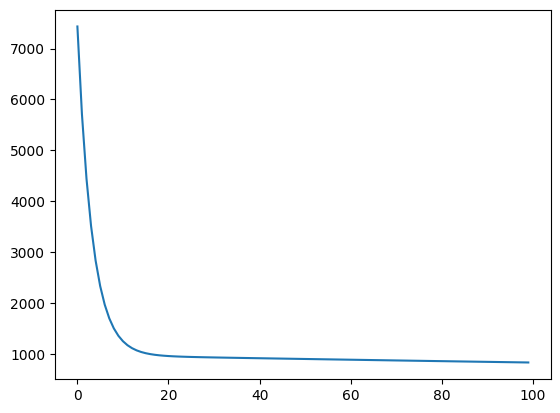

In [ ]:
#@title 오차 확인
# 1000개의 mse를 10개 단위로 확대해서 그려 본다.
import matplotlib.pyplot as plt

plt.plot(mses[:1000:10])
plt.show()

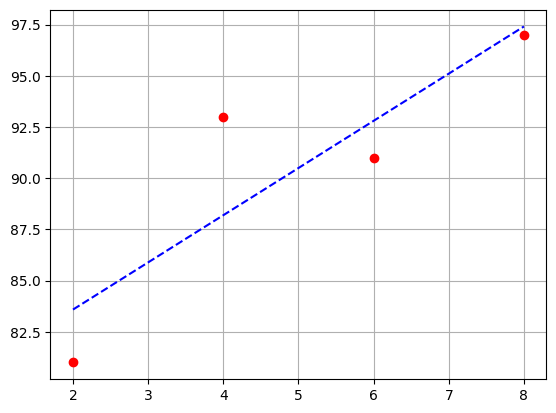

In [ ]:
#@title 결과와 예측선 그래프
plt.plot(x,y,'ro')
plt.plot(x,a*x+b,'b--')
plt.grid()
plt.show()

##  Simple Linear Regression with tensorfow
- Sequential model, Dense layer
- optimizer : sgd, loss : mse (activation : linear)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [ ]:
import numpy as np
x = np.array([2,4,6,8])
y = np.array([81,93,91,97])

In [ ]:
# 모델 생성
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1, input_dim=1))
#model.add(Dense(1))
# 최적화, loss 함수 지정
model.compile(optimizer='sgd', loss='mse')
# 초기 가중치(a, b) 출력
model.get_weights()

[array([[-0.61974967]], dtype=float32), array([0.], dtype=float32)]

In [ ]:
%%time
# 학습 실행
hist = model.fit(x,y,epochs=10000,verbose=0)

CPU times: user 5min 36s, sys: 1min 42s, total: 7min 18s
Wall time: 7min 41s


In [ ]:
model.get_weights()

[array([[2.300191]], dtype=float32), array([78.998856], dtype=float32)]

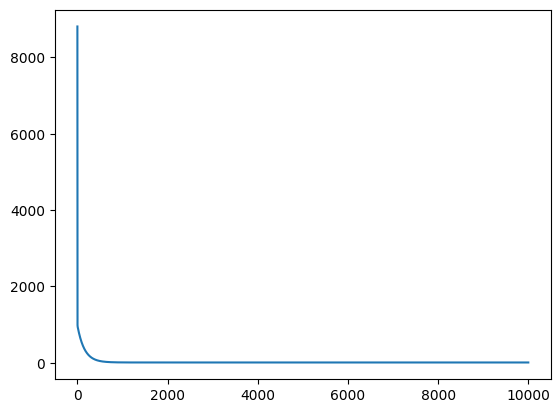

In [ ]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])

In [ ]:
model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


array([[83.599236],
       [88.199615],
       [92.8     ],
       [97.40038 ]], dtype=float32)

In [ ]:
model.get_weights()

[array([[2.300191]], dtype=float32), array([78.998856], dtype=float32)]

##  tensorflow - hidden layer
- hidden layer activation : relu

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
import numpy as np
x = np.array([2,4,6,8])
y = np.array([81,93,91,97])

In [ ]:
model = Sequential()
model.add(Dense(16, input_dim=1,activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
%%time
hist = model.fit(x,y,epochs=10000,verbose=0)

CPU times: user 5min 52s, sys: 1min 43s, total: 7min 36s
Wall time: 7min 47s


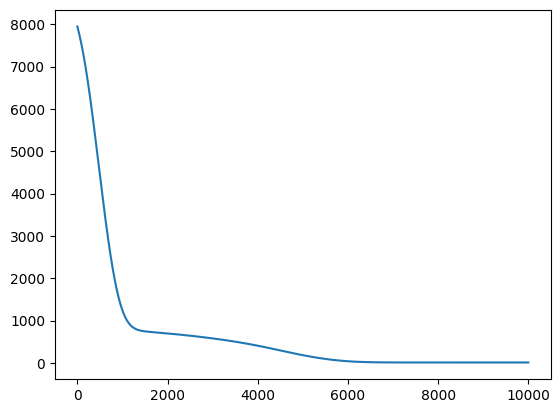

In [ ]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])

In [ ]:
import pandas as pd
df = pd.DataFrame(hist.history)
df.head()

,loss
0,7947.456055
1,7943.250488
2,7939.038086
3,7934.816406
4,7930.586914


In [ ]:
model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


array([[83.59977 ],
       [88.19988 ],
       [92.799995],
       [97.40012 ]], dtype=float32)

In [ ]:
model.get_weights()

[array([[-0.2731452 , -0.42049965, -0.32552347, -0.03867873, -0.48470598,
         -0.5865806 ,  0.5881268 , -0.08535075,  0.5562751 , -0.67417127,
         -0.32373554,  0.4346791 , -0.44601357,  0.4277325 , -0.5781234 ,
         -0.24539277]], dtype=float32),
 array([0.       , 0.       , 0.       , 4.6659794, 0.       , 0.       ,
        4.9298825, 0.       , 4.280705 , 5.3956513, 0.       , 4.3682394,
        0.       , 4.7358966, 0.       , 0.       ], dtype=float32),
 array([[-0.3722226 ],
        [ 0.5004858 ],
        [ 0.02450854],
        [ 3.327788  ],
        [ 0.03522217],
        [ 0.57628024],
        [ 2.059075  ],
        [ 0.4014157 ],
        [ 2.4288905 ],
        [ 3.3058825 ],
        [-0.01775819],
        [ 2.5498707 ],
        [-0.48076043],
        [ 2.3075182 ],
        [ 0.01449734],
        [-0.11124784]], dtype=float32),
 array([3.01989], dtype=float32)]

In [ ]:
model.save("lr_hidden.keras")

## 단순 선형회귀 연습 - flights
- 미국 월별/연도별 비행기 탑승객 기록
- 월 단위 합계 및 연도에 대한 탑승객 예측

### 데이터 로딩 및 가공

In [4]:
#@title 데이터 로딩
import seaborn as sns

flights = sns.load_dataset('flights')
flights.head(12)

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
5,1949,Jun,135
6,1949,Jul,148
7,1949,Aug,148
8,1949,Sep,136
9,1949,Oct,119


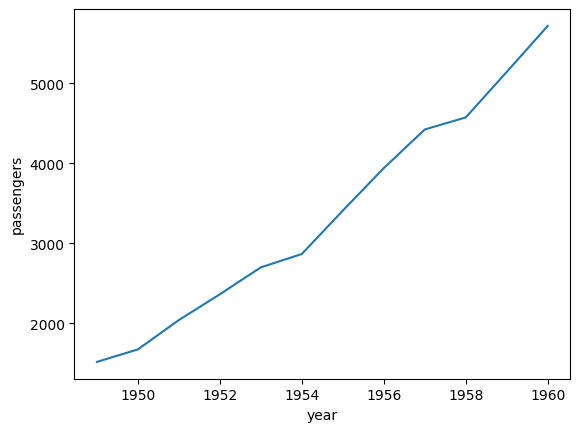

In [5]:
#@title 연도별 승객 수 증가 추이 그래프
import matplotlib.pyplot as plt

flt_year = flights.groupby("year", as_index=False)["passengers"].sum()
sns.lineplot(data=flt_year, x="year", y="passengers")
plt.show()

<Axes: xlabel='year', ylabel='month'>

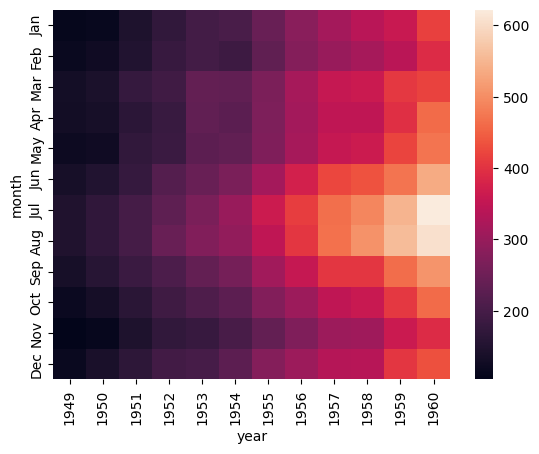

In [6]:
#@title 분석을 위한 히트맵
#df = flights.replace({'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6, 'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12})

df_pivot = flights.pivot(index='month', columns='year', values='passengers')
sns.heatmap(df_pivot)

In [7]:
#@title 데이터 분리 및 표준화
# 표준화를 하지 않으면 입력값이 커서 발산한다.
def norm_year(y) :
  return (y.astype('float32') - y.mean()) / y.std()

norm_year(flt_year.year)[:5]

,year
0,-1.525426
1,-1.248075
2,-0.970725
3,-0.693375
4,-0.416025


### 일반적인 학습 방법

In [15]:
#@title model 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='sgd', loss='mse')
print('초기값 : ', model.get_weights())


초기값 :  [array([[1.1754421]], dtype=float32), array([0.], dtype=float32)]


In [16]:
#@title 학습
%%time
hist = model.fit(norm_year(flt_year.year), flt_year.passengers, epochs=10000, verbose=0)

model.get_weights()

CPU times: user 5min 47s, sys: 1min 39s, total: 7min 26s
Wall time: 7min 35s


[array([[1381.238]], dtype=float32), array([3363.5774], dtype=float32)]

In [10]:
#@title 모델 저장
model.save('ml_flights.keras')

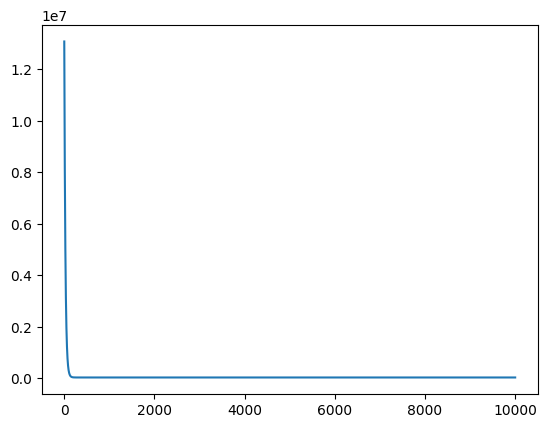

In [11]:
#@title loss 차트 생성
import matplotlib.pyplot as plt

plt.plot(hist.history['loss'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


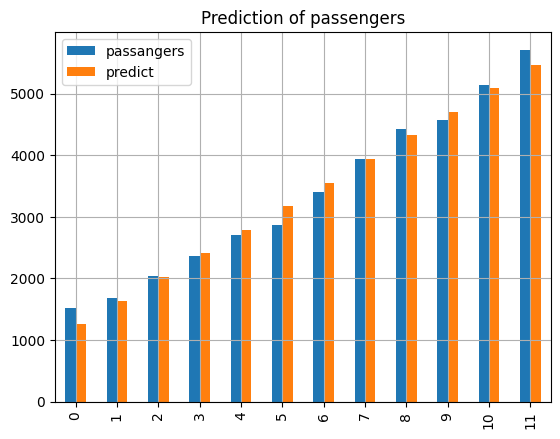

In [12]:
#@title 예측 실행 및 결과 출력
pred = model.predict(norm_year(flt_year.year))

import pandas as pd
import numpy as np

res = pd.DataFrame({'passangers':flt_year.passengers, 'predict':np.reshape(pred, -1)})

res.plot.bar(title='Prediction of passengers')
plt.grid()

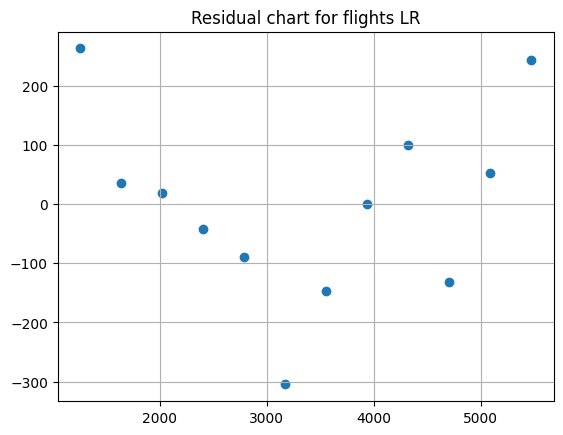

In [13]:
#@title 잔차 그래프 (Regidual chart)
# x축 : pred(x), y축 : 잔차(y - pred(x))

plt.title('Residual chart for flights LR')
plt.grid()
plt.scatter(res['predict'], res['passangers']-res['predict'])

### 잔차 분포에 따른 해결 방법

상황별 조치 가이드  
1️⃣ "나팔/부채 모양" 인가요? (Fan Shape)  
모양: 가로축(Year)이 커질수록, 점들이 위아래로 점점 더 넓게 퍼져나가는 형태.  
원인: 이분산성(Heteroscedasticity) 때문입니다. (데이터 값이 커질수록 오차도 같이 커지는 현상)  
조치: 네, 무조건 log1p를 적용해야 합니다. 로그 변환은 큰 값들을 압축시켜서 퍼짐 정도를 일정하게 맞춰주는 역할을 합니다.  

2️⃣ "U자 혹은 곡선 모양" 인가요? (Curved Shape)  
모양: 점들이 무작위로 퍼져있는 게 아니라, 어떤 곡선을 그리듯이 줄을 서 있는 형태. (예: 아래로 처졌다가 다시 위로 올라가는 U자 모양)  
원인: 비선형성(Non-linearity) 때문입니다. 데이터가 직선이 아니라 곡선으로 변하고 있는데 모델이 직선으로만 예측하려 해서 생기는 오류니다.  
조치: 네, log1p를 시도해 보셔야 합니다. 로그는 지수함수적 성장을 "직선"에 가깝게 펴주는 효과가 있기 때문입니다. (아주 심하게 곡선이면 Polynomial Regression 같은 다른 방식을 써야 할 수도 있지만, log1p가 가장 첫번째로 시도할 만한 좋은 방법입니다.)  

3️⃣ "무질서하게 퍼져있는 점들" 인가요? (Random Cloud)  
모양: 어떤 규칙적임 없이 위아래로 무작위하게 흐트라퍼져있는 모양. (마치 구름이나 안개 같은 모양)  
원인: 아무 문제도 없는 상태입니다. 모델이 데이터의 패턴을 아주 잘 잡아내고 있다는 뜻입니다.  
조치: 아니요, 지금 그대로가 좋습니다. log1p를 시켜서 오히려 좋은 모델을 망쳐버릴 수도 있습니다.

학습 : np.log1p(passengers)
예측 : np.expm1(predict_value)

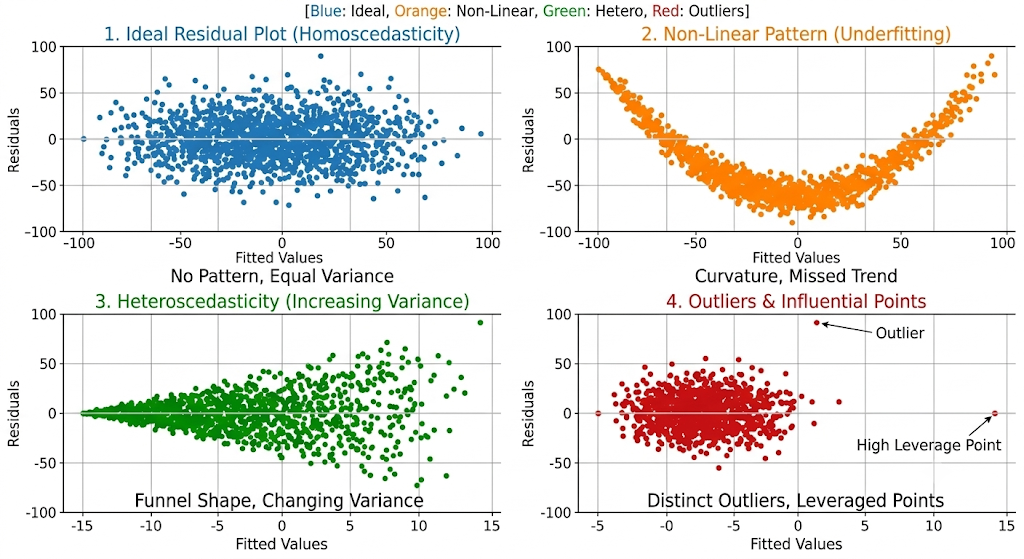

|패턴 번호 / 유형|	원인 분석|	해결 방법|
|-|-|-|
|1. 이상적인 잔차</br> (Ideal)	|잔차가 0을 중심으로 특정 패턴 없이 무작위 분포</br> (선형회귀 기본 가정 충족)	|현재 모델 유지 (별도 조치 필요 없음)|
|2. 비선형 패턴 </br>(Non-Linear)	|독립변수와 종속변수 간의 비선형(곡선) 관계를 모델이 반영하지 못함	|• 다항 회귀(Polynomial Regression) 적용 (x2 ,x3 등 추가) </br> • 비선형 모델(결정 트리, Random Forest, XGBoost 등)로 교체|
|3. 이산성 / 등분산성 위반 </br>(Heteroscedasticity)	|예측값이 증가함에 따라 오차의 변동폭(분산)이 점점 커지거나 작아짐|	• 종속변수 y에 로그 변환(log1p) 또는 Box-Cox 변환 적용 </br> • 가중 최소제곱법(WLS, Weighted Least Squares) 사용|
|4. 이상치 및 고영향점</br> (Outliers & High Leverage)|	회귀 직선을 강하게 왜곡하는 극단적인 이상치가 존재함|• 이상치 데이터의 원인 확인 후 제거 또는 대치(Imputation)  </br>• 이상치 영향에 강한 로버스트 회귀(Robust Regression, RANSAC, Huber) 적용|

In [17]:
#@title model 생성 (동일한 모델)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='sgd', loss='mse')
print('초기값 : ', model.get_weights())


초기값 :  [array([[-0.22833335]], dtype=float32), array([0.], dtype=float32)]


In [18]:
#@title 학습
%%time

import numpy as np

hist = model.fit(norm_year(flt_year.year), np.log(flt_year.passengers), epochs=10000, verbose=0)

model.get_weights()

CPU times: user 5min 44s, sys: 1min 38s, total: 7min 23s
Wall time: 7min 34s


[array([[0.4378363]], dtype=float32), array([8.036004], dtype=float32)]

In [19]:
#@title 모델 저장
model.save('ml_log_flights.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


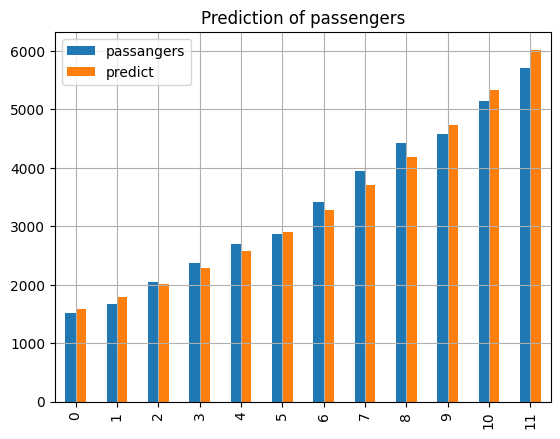

In [20]:
#@title 예측 실행 및 결과 출력
pred = np.exp(model.predict(norm_year(flt_year.year)))

import pandas as pd
import numpy as np

res = pd.DataFrame({'passangers':flt_year.passengers, 'predict':np.reshape(pred, -1)})

res.plot.bar(title='Prediction of passengers')
plt.grid()

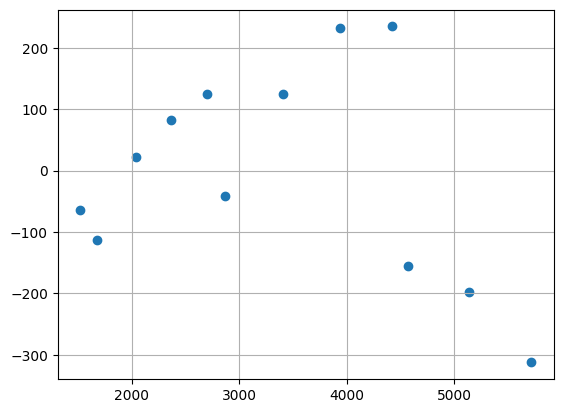

In [22]:
#@title 잔차 그래프 (Regidual chart)

plt.grid()
plt.scatter(res['passangers'], res['passangers']-res['predict'])

## 다중 선형회귀 연습 - tips
- 여러 개의 독립변수 중 유의미한 상관 관계가 있는 독립 변수를 취한다.
  - 상관계수 $ r = \frac {Cov(x,y)}{\sigma x \cdot \sigma y} \ , \ -1 \le r \le 1 $
  - 엑셀 : correl(), pandas : corr()
  - seaborn : sns.heatmap(x, annot=True)
  - 데이터의 이상치 분포 확인 - 상자수염그림 : sns.boxplot(x)

In [ ]:
#@title 데이터 로딩
import seaborn as sns
tips = sns.load_dataset('tips')
print(tips.day.unique())
tips.head()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
#@title 데이터 정제
tips.replace({'Male':1, 'Female':2}, inplace=True)
tips.replace({'Thur':1, 'Fri':2,'Sat':3,'Sun':4}, inplace=True)
tips.replace({'Lunch':1, 'Dinner':2}, inplace=True)
tips.replace({'No':1, 'Yes':2}, inplace=True)
tips.head()

/tmp/ipykernel_751/1588646021.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tips.replace({'No':1, 'Yes':2}, inplace=True)
/tmp/ipykernel_751/1588646021.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  tips.replace({'No':1, 'Yes':2}, inplace=True)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,2,1,4,2,2
1,10.34,1.66,1,1,4,2,3
2,21.01,3.50,1,1,4,2,3
3,23.68,3.31,1,1,4,2,2
4,24.59,3.61,2,1,4,2,4


<Axes: >

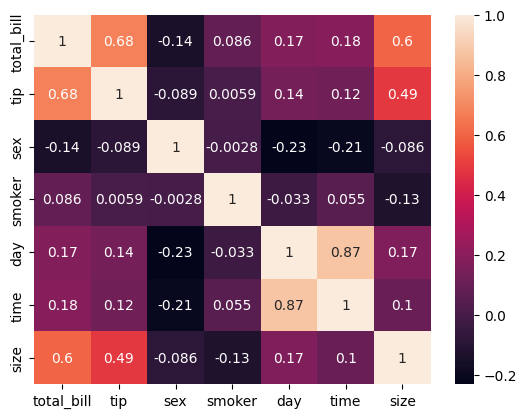

In [ ]:
#@title 상관계수 r 확인
sns.heatmap(tips.corr(),annot=True)

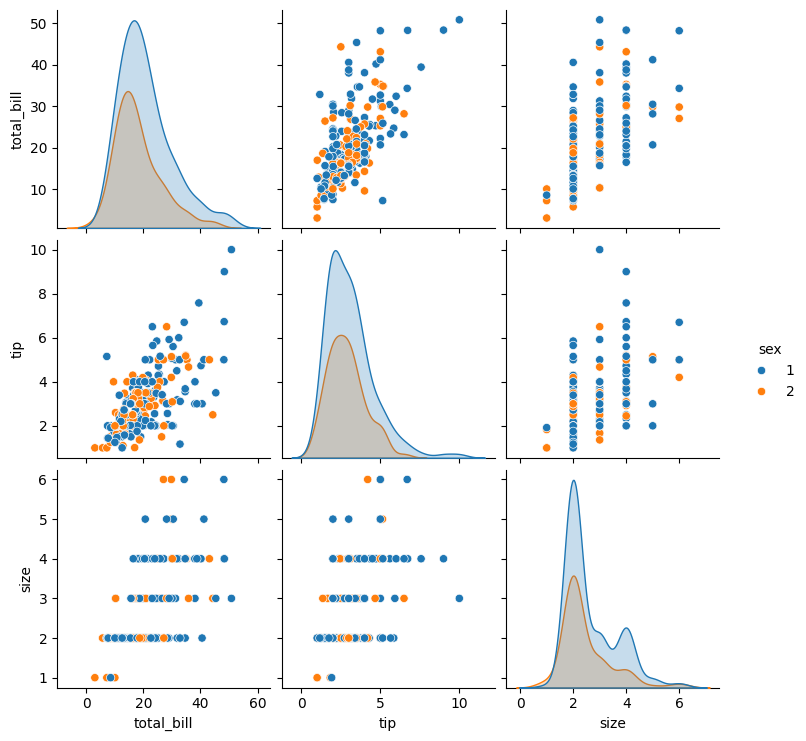

In [ ]:
sns.pairplot(tips, hue='sex')

In [ ]:
#@title 학습/결과 데이터 분리
x = tips.iloc[:,[0,6]]
y = tips['tip']

In [ ]:
#@title 선형회귀 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(16,activation='relu'))
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
model.get_weights()

[array([[ 0.04342574, -0.00098294,  0.1918484 , -0.4441722 ,  0.30439335,
          0.09497303,  0.31324142, -0.4705764 ,  0.19863623, -0.06937957,
         -0.21891952,  0.00970906,  0.3518929 , -0.47161734,  0.29333216,
         -0.30547488],
        [-0.31775832, -0.34863207, -0.11685306, -0.49696055,  0.20309126,
         -0.44225746,  0.12055618,  0.5567932 ,  0.03909206, -0.17513546,
          0.5424117 , -0.55628675, -0.44385463, -0.13759583, -0.49581885,
          0.3380068 ]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32),
 array([[-0.0243029 ],
        [-0.17540148],
        [ 0.47025585],
        [ 0.03539926],
        [ 0.1959557 ],
        [ 0.3579998 ],
        [ 0.21212822],
        [ 0.24383003],
        [-0.08911067],
        [-0.5134994 ],
        [-0.58368754],
        [-0.22525883],
        [-0.09950247],
        [ 0.10491407],
        [-0.01456004],
        [-0.5352814 ]], dtype=float32),
 array([0.],

In [ ]:
#@title 학습 시행
%%time
hist = model.fit(x,y,epochs=1000,verbose=0)

CPU times: user 52.4 s, sys: 11.5 s, total: 1min 3s
Wall time: 1min 1s


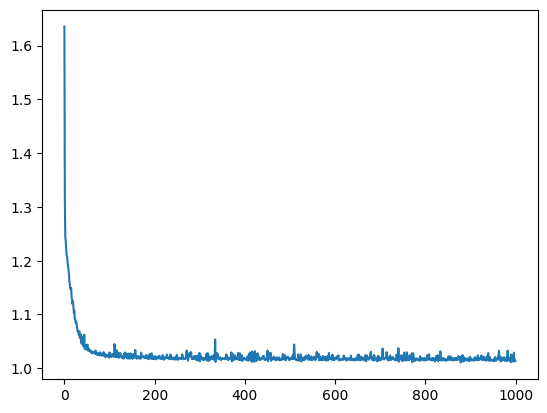

In [ ]:
#@title loss 차트
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])

In [ ]:
#@title a, b 값 확인
model.get_weights()

[array([[ 0.09554665, -0.00098294,  0.17082232, -0.4441722 ,  0.27894217,
          0.04053175,  0.28832892, -0.4705764 ,  0.20365663, -0.06937957,
         -0.21891952,  0.00970906,  0.35928804, -0.47161734,  0.28291607,
         -0.30547488],
        [-0.34806633, -0.34863207, -0.06352448, -0.49696055,  0.25292277,
         -0.41200608,  0.1705607 ,  0.5567932 , -0.03167193, -0.17513546,
          0.5424117 , -0.55628675, -0.51580006, -0.13759583, -0.60419977,
          0.3380068 ]], dtype=float32),
 array([-0.21401753,  0.        ,  0.2992284 ,  0.        ,  0.29761422,
        -0.56554794,  0.29701546,  0.        , -0.3225657 ,  0.        ,
         0.        ,  0.        , -0.32864046,  0.        , -0.40026844,
         0.        ], dtype=float32),
 array([[-0.12413285],
        [-0.17540148],
        [ 0.44809365],
        [ 0.03539926],
        [ 0.18421206],
        [ 0.53319305],
        [ 0.19817127],
        [ 0.24383003],
        [-0.10672428],
        [-0.5134994 ],
      

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


<Axes: >

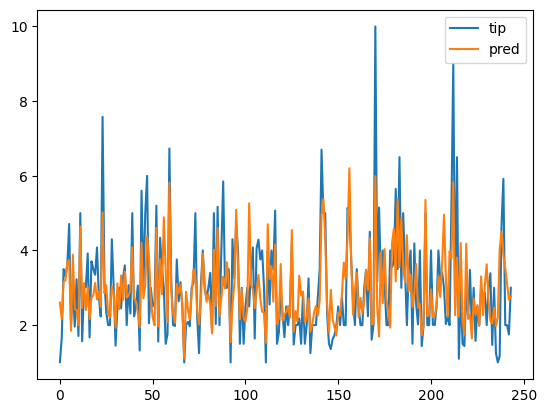

In [ ]:
#@title 학습 데이터와 예측 결과 비교
import numpy as np
df = pd.DataFrame({'tip':tips['tip'],'pred':np.reshape(model.predict(x), -1)})
df.plot()

<Axes: >

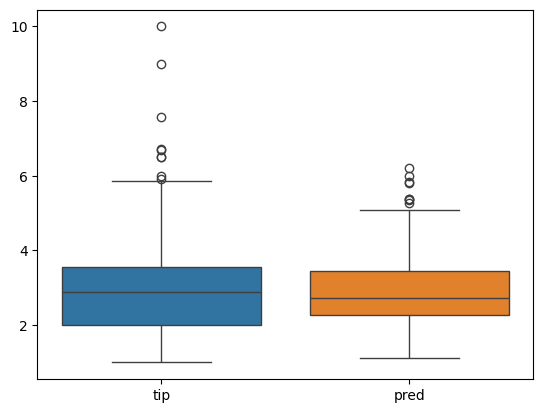

In [ ]:
#@title 이상치 확인
sns.boxplot(df)

In [ ]:
tips.iloc[df[df.tip>6].index,:]

,total_bill,tip,sex,smoker,day,time,size
23,39.42,7.58,1,1,3,2,4
59,48.27,6.73,1,1,3,2,4
141,34.30,6.70,1,1,1,1,6
170,50.81,10.00,1,2,3,2,3
183,23.17,6.50,1,2,4,2,4
212,48.33,9.00,1,1,3,2,4
214,28.17,6.50,2,2,3,2,3


## 다중선형회귀 - Diamonds
- 중요한 독립 변수 : carat, clarity, color
- 종속 변수 : price
- null 값의 개수 확인 : dm.isnull().sum(axis=1)
- 범주형 변수의 치환 : dm.color.map({'E':0, 'I':1, ...)
- 범주형 변수의 one-hot encoding : pd.get_dummies()


### 데이터 로딩 및 정제

In [5]:
#@title 데이터 로딩
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dm = sns.load_dataset('diamonds')
dm.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
#@title 데이터 확인
# 결측치 확인
print(dm.isnull().sum())

# 데이터 통계치 확인
dm.describe()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [8]:
#@title 범주형 변수 확인
print(dm.cut.unique())
print(dm.clarity.unique())
print(dm.color.unique())

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']


In [6]:
#@title 범주형 -> 정수형 치환
dm1 = dm.copy()

dm1['cut'] = dm1['cut'].cat.codes
dm1['color'] = dm1['color'].cat.codes
dm1['clarity'] = dm1['clarity'].cat.codes

dm1.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,0,1,6,61.5,55.0,326,3.95,3.98,2.43
1,0.21,1,1,5,59.8,61.0,326,3.89,3.84,2.31
2,0.23,3,1,3,56.9,65.0,327,4.05,4.07,2.31
3,0.29,1,5,4,62.4,58.0,334,4.20,4.23,2.63
4,0.31,3,6,6,63.3,58.0,335,4.34,4.35,2.75


<Axes: >

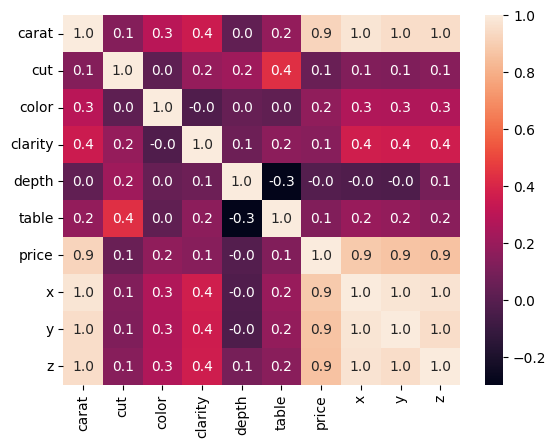

In [17]:
#@title corr heatmap
sns.heatmap(dm1.corr(), annot=True, fmt='.1f')

In [7]:
#@title 독립변수와 종속변수 할당
X = dm1[['carat','cut','color','clarity']]
Y = dm1['price']
X, Y

(       carat  cut  color  clarity
 0       0.23    0      1        6
 1       0.21    1      1        5
 2       0.23    3      1        3
 3       0.29    1      5        4
 4       0.31    3      6        6
 ...      ...  ...    ...      ...
 53935   0.72    0      0        5
 53936   0.72    3      0        5
 53937   0.70    2      0        5
 53938   0.86    1      4        6
 53939   0.75    0      0        6
 
 [53940 rows x 4 columns],
 0         326
 1         326
 2         327
 3         334
 4         335
          ... 
 53935    2757
 53936    2757
 53937    2757
 53938    2757
 53939    2757
 Name: price, Length: 53940, dtype: int64)

<Axes: >

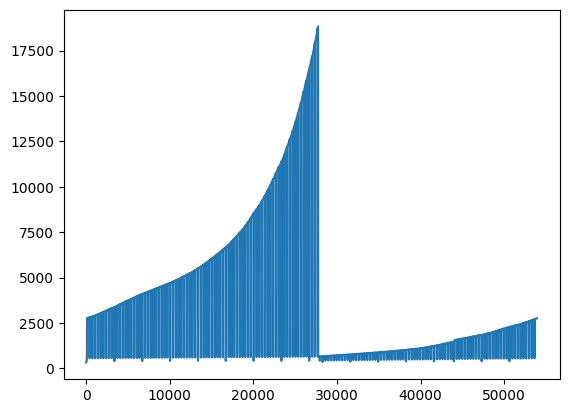

In [19]:
#@title price 확인
Y.plot()

### 모델 생성 및 학습

In [20]:
#@title 선형회귀모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(1))
print(model.summary())
model.compile(optimizer='sgd', loss='mse')
model.get_weights()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

None


[array([[ 0.08858311],
        [-0.5933456 ],
        [-0.8234656 ],
        [-0.05439162]], dtype=float32),
 array([0.], dtype=float32)]

In [21]:
#@title 학습
%%time
history = model.fit(X, Y, epochs=1000, verbose=0)
model.get_weights()

CPU times: user 1h 11min 3s, sys: 5min 45s, total: 1h 16min 48s
Wall time: 59min 50s


In [23]:
model.save('diamonds1000.keras')
model.get_weights()

[array([[8761.71   ],
        [-150.26768],
        [-334.86224],
        [-500.04263]], dtype=float32),
 array([-4.9609003], dtype=float32)]

In [24]:
model.evaluate(X, Y)

1686/1686 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1529724.1250


1529724.125

In [8]:
import tensorflow as tf

new_model = tf.keras.models.load_model('diamonds1000.keras')

print(new_model.summary())
new_model.get_weights()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (32.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


[array([[8761.71   ],
        [-150.26768],
        [-334.86224],
        [-500.04263]], dtype=float32),
 array([-4.9609003], dtype=float32)]

In [10]:
import pandas as pd
import numpy as np
pred = new_model.predict(X)

df = pd.DataFrame({'price':Y, 'pred':np.reshape(pred, -1)})

1686/1686 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


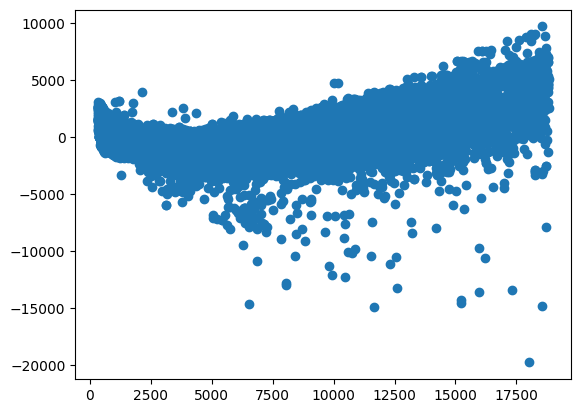

In [11]:
#@title 잔차 그래프, 이산분산성(Heteroscedasticity)을 보임
import matplotlib.pyplot as plt

plt.scatter(df.price, df.price-df.pred)

#### 개선 방법
- log(Y)로 학습, exp(pred)로 예측